In [286]:
import numpy as np
import ocpy 
from ocpy.pace import io as pace_io
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
from geopy.geocoders import Nominatim
import cartopy.feature as cfeature
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from geopy import distance
from sklearn.metrics.pairwise import haversine_distances
from math import radians

In [287]:
# Given data file
PACE_datafile = '/Users/kassidylam/UCSC/research/Ocean_Color/summer25/PACE_data/PACE_OCI.20250401T202905.L2.OC_AOP.V3_0.nc'
ds, flags = pace_io.load_oci_l2(PACE_datafile)
# ds = xr.open_dataset('/Users/kassidylam/UCSC/research/Ocean_Color/summer25/PACE_data/PACE_OCI.20250401T202905.L2.OC_AOP.V3_0.nc')

In [288]:
# Inspecting data set
ds
# print(ds.latitude[1000,1000])
# print(ds['longitude'][1000,1000])
# ds.values
# ds.coords
# print(ds.wavelength.values)
# ds.wavelength[38]
# ds.dims
# ds.attrs
# ds.latitude
# ds.Rrs[1,1,1]
# # ds.latitude[1,1]
# ds.longitude[1,1]
# ds.longitude

<xarray.Dataset> Size: 3GB
Dimensions:     (x: 1710, y: 1272, wl: 172)
Coordinates:
    latitude    (x, y) float32 9MB 8.01 8.02 8.03 8.04 ... 30.95 30.97 30.98
    longitude   (x, y) float32 9MB -125.9 -125.9 -125.8 ... -104.5 -104.5 -104.4
    wavelength  (wl) int32 688B 346 348 351 353 356 358 ... 712 713 714 717 719
Dimensions without coordinates: x, y, wl
Data variables:
    Rrs         (x, y, wl) float32 1GB -3.277e+04 -3.277e+04 ... -3.277e+04
    Rrs_unc     (x, y, wl) float32 1GB -3.277e+04 -3.277e+04 ... -3.277e+04
Attributes: (12/45)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20250401T202905.L2.OC_AOP.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data2/sdpsoper/vdc/vpu21/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -101.80601
    geospatial_lon_min:                -131.308
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0011428594589233

In [289]:
# Flags represents quality of data...
flags
# ds.Rrs.shape
# ds.latitude.shape
# ds.longitude.shape
# plt.plot(ds['longitude'])
# plt.plot(ds.longitude)
# # # fig = plt.figure()
# # # ax = fig.add_subplot(projection='3d')
# plt.plot(ds.wavelength)
# plt.show()

masked_array(
  data=[[1073742384, 1073742368, 1073742368, ..., 1073741860, 1073741860,
         1073741857],
        [1073742384, 1073742368, 1073742368, ..., 1073741860, 1073741860,
         1073741857],
        [1073742384, 1073742368, 1073742368, ..., 1073741860, 1073741860,
         1073741857],
        ...,
        [1073742384, 1610613024, 1610613024, ..., 1073742370, 1073742370,
         1073742370],
        [1073742384, 1610613024, 1610613024, ..., 1073742114, 1073742370,
         1073742370],
        [1073742384, 1610613028,  536871200, ..., 1073742114, 1073742370,
         1073742370]],
  mask=False,
  fill_value=np.int64(999999),
  dtype=int32)

In [290]:
# Looking at specific Rrs coordinates
# ds.Rrs[1000,1000,:]
# ds.Rrs[1000,1000,150]
print(ds.Rrs[:,:,38])
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.plot(ds['Rrs'][1000,1000,150])

<xarray.DataArray 'Rrs' (x: 1710, y: 1272)> Size: 9MB
array([[-3.2767000e+04, -3.2767000e+04, -3.2767000e+04, ...,
         6.0920008e-03,  6.2140003e-03, -3.2767000e+04],
       [-3.2767000e+04, -3.2767000e+04, -3.2767000e+04, ...,
         6.3060001e-03,  6.2099993e-03, -3.2767000e+04],
       [-3.2767000e+04, -3.2767000e+04, -3.2767000e+04, ...,
         6.5780021e-03,  6.2419996e-03, -3.2767000e+04],
       ...,
       [-3.2767000e+04,  2.1592000e-02,  2.3306001e-02, ...,
        -3.2767000e+04, -3.2767000e+04, -3.2767000e+04],
       [-3.2767000e+04,  2.1930002e-02,  2.3526002e-02, ...,
        -3.2767000e+04, -3.2767000e+04, -3.2767000e+04],
       [-3.2767000e+04,  2.1852002e-02,  2.3302000e-02, ...,
        -3.2767000e+04, -3.2767000e+04, -3.2767000e+04]],
      shape=(1710, 1272), dtype=float32)
Coordinates:
    latitude    (x, y) float32 9MB 8.01 8.02 8.03 8.04 ... 30.95 30.97 30.98
    longitude   (x, y) float32 9MB -125.9 -125.9 -125.8 ... -104.5 -104.5 -104.4
    wavelengt

In [291]:
# If data is good, then flags should be 0...
good = flags == 0
np.any(good)
# ds.values
# ds.attrs
ds.Rrs[10,10,10]

<xarray.DataArray 'Rrs' ()> Size: 4B
array(-32767., dtype=float32)
Coordinates:
    latitude    float32 4B 8.212
    longitude   float32 4B -125.4
    wavelength  int32 4B 371

## Plot Rrs at 440nm geographically, include land - cartopy


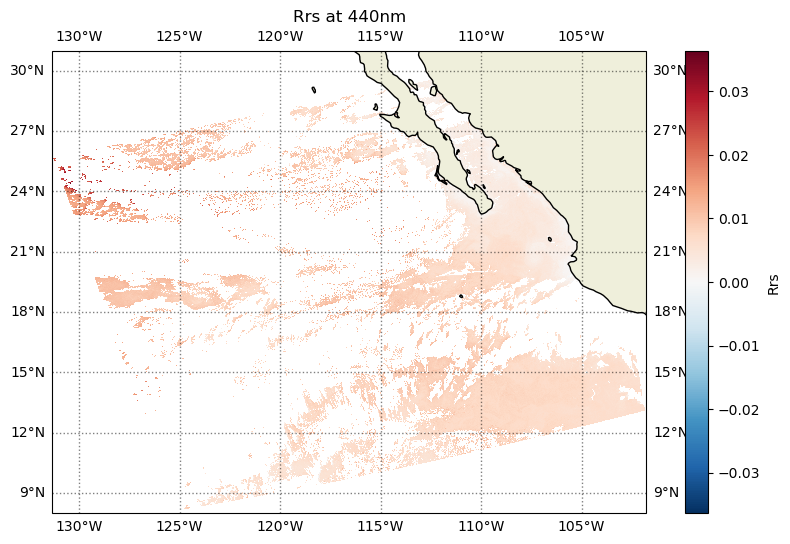

In [292]:
fig = plt.figure(figsize=(10,6))

# Create axes with Plate Carree projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Select wavelength at 440nm
chosen_wl = ds.Rrs.isel(wl=38)


# Modify Rrs values
bad = chosen_wl.data <= -32767
chosen_wl.data[bad] =np.nan

# Creates gridded colored rectangles
# Plot using the axes we creates, geographic coordinates
chosen_wl.plot.pcolormesh(x='longitude', y='latitude', ax=ax, transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND)

gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1,
        color='black', alpha=0.5, linestyle=':', draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = True
gl.ylabels_right=False
gl.xlines = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'color': 'black'}
gl.ylabel_style = {'color': 'black'}
ax.set_title("Rrs at 440nm")
plt.show()

In [293]:
chosen_wl
# Modify some Rrs values to NaN
bad = chosen_wl.data <= -32767
chosen_wl.data[bad] =np.nan

## Find closest location from Baja California to SCMW

In [294]:
# Finding lat and lon of SCMW
geolocator = Nominatim(user_agent="googlemaps")
location = geolocator.geocode("21 Municipal Wharf, Santa Cruz, CA 95060")
# print(location.address)
print((location.longitude, location.latitude))
# print(location.raw)

(-122.0237367, 36.9626398)


In [296]:
# Calculate shortest distance from dataset to SCMW using Haversine distance
def calculate_distances_sklearn(origin_lat, origin_lon, points_array):
    # Convert to radians
    origin = np.array([[radians(origin_lat), radians(origin_lon)]])
    destinations = np.radians(points_array[:, [1, 0]])  # Note: lon, lat order for sklearn
    # Calculate distances (returns in radians)
    distances_rad = haversine_distances(origin, destinations)
    # Convert to kilometers (Earth radius = 6371 km)
    distances_km = distances_rad * 6371
    return distances_km[0]  # Return first row since we have one origin point

# Organize lat and lon arrays
# First method
longitude = ds.longitude[:,0]  #1710
latitude = ds.latitude[0,:]  #1272

# print(longitude)
# Second method
lon_flat = ds.longitude.values.flatten()
lat_flat = ds.latitude.values.flatten()
# print(latitude)
# Fill in zeros for remaining latitude rows

# Start with filling all zeros
padded_latitude = np.full(longitude.shape[0], 0.0)
# Fill with actual lat values, rest zeros
padded_latitude[:len(latitude)] = latitude
# print(padded_latitude)
sklearn_array = np.stack((lon_flat, lat_flat), axis=1)
# data = np.column_stack((longitude, padded_latitude))

print("Data: ", sklearn_array)
# Make sure it is Nx2
print(sklearn_array.shape)

distances_to_scmw = calculate_distances_sklearn(36.9626398, -122.0237367, sklearn_array)
print("Array of distances to SCMW: ", distances_to_scmw)
print("Shortest distance to SCMW: ", distances_to_scmw.min())
min_idx = np.argmin(distances_to_scmw)
closest_point = sklearn_array[min_idx]
print("Closest point to SCMW:", closest_point)

Data:  [[-125.935165    8.009501]
 [-125.871315    8.019734]
 [-125.80822     8.029866]
 ...
 [-104.54432    30.953363]
 [-104.472664   30.965227]
 [-104.401535   30.976814]]
(2175120, 2)
Array of distances to SCMW:  [3243.614682   3241.70393534 3239.82548802 ... 1741.69666036 1747.16986565
 1752.61917724]
Shortest distance to SCMW:  1006.6051103945499
Closest point to SCMW: [-119.478584   28.166668]
